In [1]:

pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\HARSHA
[nltk_data]     VARDHINI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
df = pd.read_csv("customer_support_tickets"".csv")

df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [6]:
df['text'] = (
    df['Ticket Subject'].astype(str)
    + " "
    + df['Ticket Description'].astype(str)
)

df[['text']].head()

,text
0,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility I'm having an issue w...
2,Network problem I'm facing a problem with my {...
3,Account access I'm having an issue with the {p...
4,Data loss I'm having an issue with the {produc...


In [7]:
print(df[['text','Ticket Type','Ticket Priority']].isnull().sum())

text               0
Ticket Type        0
Ticket Priority    0
dtype: int64


In [8]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

df[['clean_text']].head()

,clean_text
0,product setup im issue productpurchased please...
1,peripheral compatibility im issue productpurch...
2,network problem im facing problem productpurch...
3,account access im issue productpurchased pleas...
4,data loss im issue productpurchased please ass...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

print(X.shape)

(8469, 5000)


In [10]:
y_type = df['Ticket Type']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_type,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.naive_bayes import MultinomialNB

type_model = MultinomialNB()

type_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
type_pred = type_model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    type_pred
)

print("Ticket Type Accuracy:", accuracy)

Ticket Type Accuracy: 0.19067296340023612


In [15]:
print(df['Ticket Type'].value_counts())
print(df['Ticket Type'].nunique())

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
5


In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", accuracy)


Logistic Regression Accuracy: 0.19303423848878395


In [22]:
df[['Ticket Subject','Ticket Type']].head(20)

,Ticket Subject,Ticket Type
0,Product setup,Technical issue
1,Peripheral compatibility,Technical issue
2,Network problem,Technical issue
3,Account access,Billing inquiry
4,Data loss,Billing inquiry
5,Payment issue,Cancellation request
6,Refund request,Product inquiry
7,Battery life,Refund request
8,Installation support,Technical issue
9,Payment issue,Refund request


In [23]:
print(df['Ticket Priority'].value_counts())

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


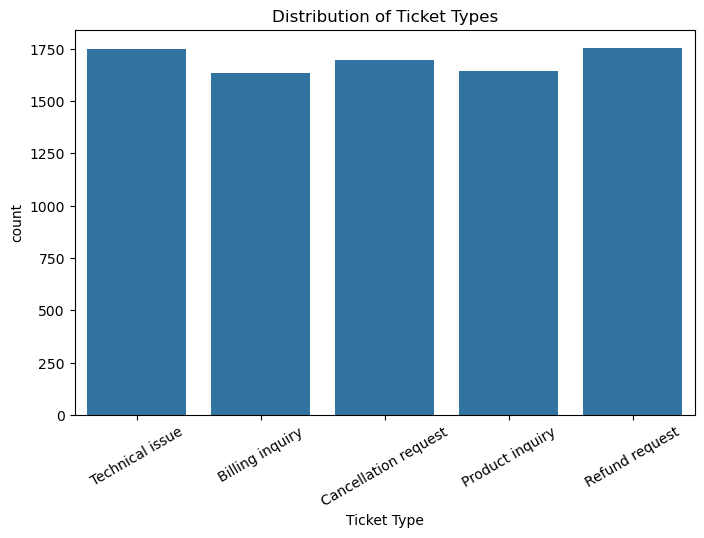

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Ticket Type',
    data=df
)

plt.xticks(rotation=30)

plt.title("Distribution of Ticket Types")

plt.show()

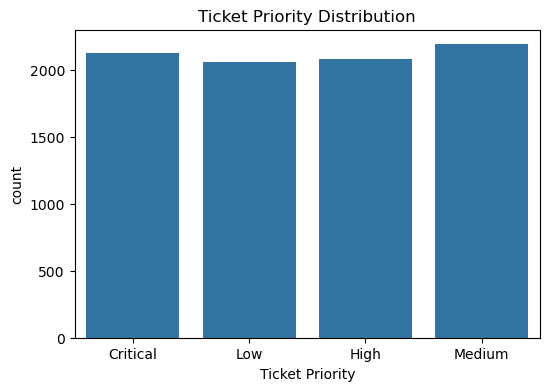

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Ticket Priority',
    data=df
)

plt.title("Ticket Priority Distribution")

plt.show()

In [33]:
y_priority = df['Ticket Priority']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)
priority_model = LogisticRegression(
    max_iter=1000
)

priority_model.fit(
    X_train_p,
    y_train_p
)
priority_pred = priority_model.predict(
    X_test_p
)
priority_accuracy = accuracy_score(
    y_test_p,
    priority_pred
)

print(
    "Priority Accuracy:",
    priority_accuracy
)

Priority Accuracy: 0.2603305785123967


In [34]:
print(
    classification_report(
        y_test_p,
        priority_pred
    )
)

              precision    recall  f1-score   support

    Critical       0.25      0.26      0.25       411
        High       0.25      0.26      0.25       409
         Low       0.28      0.28      0.28       415
      Medium       0.26      0.25      0.25       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



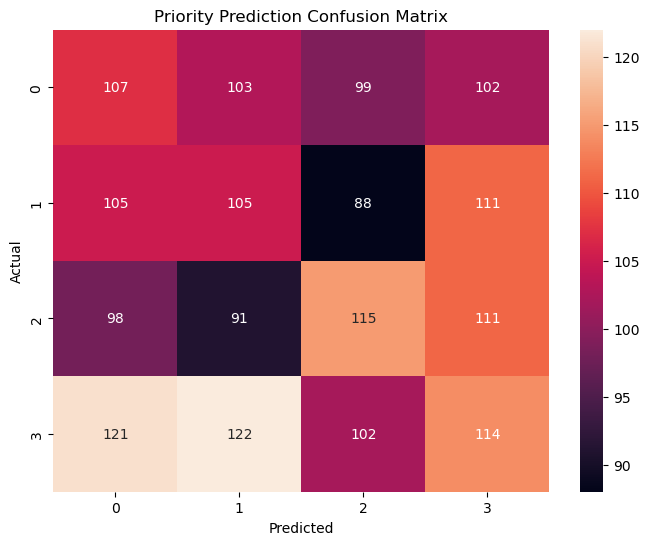

In [35]:
cm = confusion_matrix(
    y_test_p,
    priority_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Priority Prediction Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [36]:
print("Priority Accuracy:", priority_accuracy)

Priority Accuracy: 0.2603305785123967
